# 03D – Hyperparameter Tuning (Enterprise)

Optimize the production Random Forest model using the cleaned bankruptcy dataset.

## Business Objective
Identify the optimal hyperparameters for the Random Forest model to maximize predictive performance while maintaining good generalization.

In [1]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

In [2]:
DATA_PATH='../data/datasets/american_bankruptcy_cleaned.csv'

df = pd.read_csv(DATA_PATH)

target='status_label' if 'status_label' in df.columns else 'target'

if not pd.api.types.is_numeric_dtype(df[target]):
    y=df[target].map({'alive':0,'failed':1})
else:
    y=df[target]

X=df.drop(columns=[target])
if 'company_name' in X.columns:
    X=X.drop(columns=['company_name'])

X_train,X_test,y_train,y_test=train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [3]:
base_model=RandomForestClassifier(
    random_state=42,
    class_weight='balanced',
    n_jobs=1
)

param_grid={
    'n_estimators':[100,150],
    'max_depth':[10,20],
    'min_samples_split':[2,5],
    'min_samples_leaf':[1,2],
    'max_features':['sqrt']
}

search=RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_grid,
    n_iter=6,
    scoring='roc_auc',
    cv=2,
    random_state=42,
    n_jobs=1
)

SEARCH_SAMPLE_SIZE = 15000
if len(X_train) > SEARCH_SAMPLE_SIZE:
    X_train_search,_,y_train_search,_ = train_test_split(
        X_train, y_train,
        train_size=SEARCH_SAMPLE_SIZE,
        stratify=y_train,
        random_state=42
    )
else:
    X_train_search, y_train_search = X_train, y_train

search.fit(X_train_search,y_train_search)

# Refit the winning configuration on the full training set.
best_model=search.best_estimator_
best_model.fit(X_train,y_train)
joblib.dump(best_model,'../models/production_bankruptcy_model.joblib')


['../models/production_bankruptcy_model.joblib']

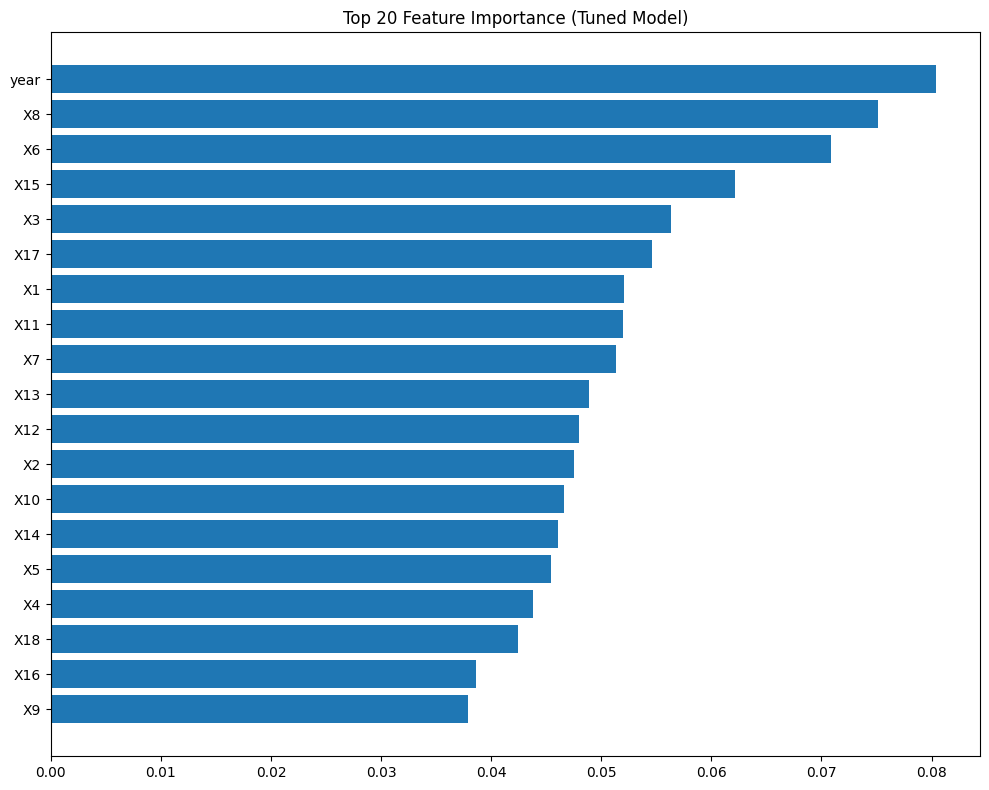

,Parameter,Value
0,n_estimators,150
1,min_samples_split,2
2,min_samples_leaf,2
3,max_features,sqrt
4,max_depth,20


,Metric,Value
0,Accuracy,0.939124
1,F1 Score,0.240887
2,ROC-AUC,0.879068


In [4]:
pred=best_model.predict(X_test)
prob=best_model.predict_proba(X_test)[:,1]

best_params=pd.DataFrame(
    search.best_params_.items(),
    columns=['Parameter','Value']
)

metrics=pd.DataFrame({
    'Metric':['Accuracy','F1 Score','ROC-AUC'],
    'Value':[
        accuracy_score(y_test,pred),
        f1_score(y_test,pred),
        roc_auc_score(y_test,prob)
    ]
})

best_params.to_csv('best_hyperparameters.csv',index=False)
metrics.to_csv('tuned_model_metrics.csv',index=False)

importance=pd.DataFrame({
    'Feature':X.columns,
    'Importance':best_model.feature_importances_
}).sort_values('Importance',ascending=False)

importance.to_csv('tuned_feature_importance.csv',index=False)

plt.figure(figsize=(10,8))
plt.barh(
    importance.head(20)['Feature'][::-1],
    importance.head(20)['Importance'][::-1]
)
plt.title('Top 20 Feature Importance (Tuned Model)')
plt.tight_layout()
plt.savefig('tuned_feature_importance.png',dpi=300)
plt.show()

display(best_params)
display(metrics)


## Deliverables

- `production_bankruptcy_model.joblib` (updated tuned model)
- `best_hyperparameters.csv`
- `tuned_model_metrics.csv`
- `tuned_feature_importance.csv`
- `tuned_feature_importance.png`

The tuned production model should be used for all subsequent explainability, validation, and deployment notebooks.

## Executive Summary

Randomized hyperparameter optimization was performed on the cleaned dataset. The best-performing Random Forest model was exported as the new production model, providing an optimized foundation for the remaining project phases.